<a href="https://colab.research.google.com/github/Pratiksha30-web/Generating-Segmentation-Masks-From-Mask2Former-/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ***Generating Segmentation Masks from Mask2Former (ADE20K)***

# ***Pratiksha Kumari***
# ***IITMCS_24061017***

In [ ]:
# -------------------------
# 1. Setup & Installs
# -------------------------
!git clone https://github.com/facebookresearch/Mask2Former.git
!pip install --upgrade pip setuptools wheel
!pip install 'git+https://github.com/facebookresearch/detectron2.git'
!pip install timm fvcore iopath pycocotools matplotlib
!pip install transformers
!pip install evaluate


fatal: destination path 'Mask2Former' already exists and is not an empty directory.
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-x37k46wv
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-x37k46wv
  Resolved https://github.com/facebookresearch/detectron2.git to commit a1ce2f956a1d2212ad672e3c47d53405c2fe4312
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.9 MB/s  0:00:00
  DEPRECATION: Building 'detectron2' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'detectron2'. Discussion can be found 

In [ ]:
# -------------------------
# 2. Imports & Config
# -------------------------
import os
import random
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
import evaluate

In [ ]:
# -------------------------
# 3. Reproducibility
# -------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# -------------------------
# 4. Dataset Preparation
# -------------------------
os.makedirs("datasets", exist_ok=True)
!wget -P datasets http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip
!unzip -q datasets/ADEChallengeData2016.zip -d datasets/

# Define validation images and masks
val_dir = "datasets/ADEChallengeData2016/images/validation"
mask_dir = "datasets/ADEChallengeData2016/annotations/validation"

val_images = sorted([os.path.join(val_dir, f) for f in os.listdir(val_dir) if f.endswith(".jpg")])
val_masks = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith(".png")])


--2025-09-20 18:46:09--  http://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip
Resolving data.csail.mit.edu (data.csail.mit.edu)... 128.52.131.233
Connecting to data.csail.mit.edu (data.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip [following]
--2025-09-20 18:46:10--  https://data.csail.mit.edu/places/ADEchallenge/ADEChallengeData2016.zip
Connecting to data.csail.mit.edu (data.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 967382037 (923M) [application/zip]
Saving to: ‘datasets/ADEChallengeData2016.zip’

ADEChallengeData201 100%[===================>] 922.57M  16.6MB/s    in 64s     

2025-09-20 18:47:15 (14.4 MB/s) - ‘datasets/ADEChallengeData2016.zip’ saved [967382037/967382037]



In [ ]:
# -------------------------
# 5. Model Setup
# -------------------------
processor = AutoImageProcessor.from_pretrained(
    "facebook/mask2former-swin-large-ade-semantic"
)
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-large-ade-semantic"
)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:410: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/866M [00:00<?, ?B/s]

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=192, out_features=192, bias=True)
                      (key): Linear(in_features=192, out_features=192, bias=True)
                      (valu

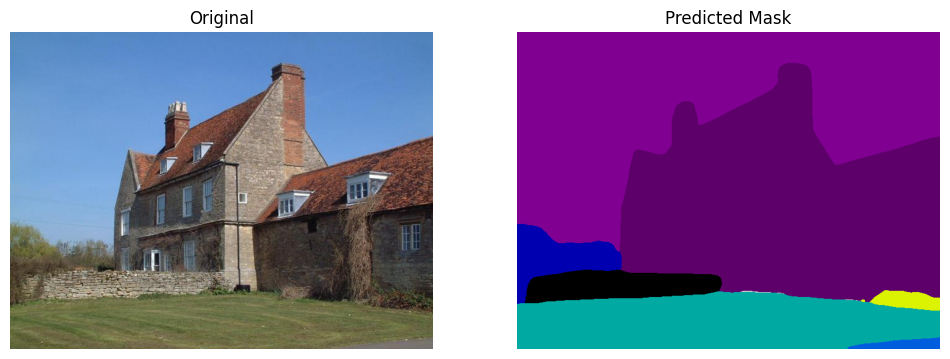

In [ ]:
# -------------------------
# 6. Single Image Inference & Visualization
# -------------------------
def visualize_single_image(img_path):
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    seg_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].cpu().numpy()

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(seg_map, cmap="nipy_spectral")
    plt.title("Predicted Mask")
    plt.axis("off")
    plt.show()

# Test with one image
visualize_single_image(val_images[0])

In [ ]:
# -------------------------
# 7. Evaluation on Multiple Images
# -------------------------
metric = evaluate.load("mean_iou")

for img_path, gt_path in tqdm(zip(val_images[:500], val_masks[:500]), total=500):
    # Load and preprocess image
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    seg_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].cpu().numpy()

    # Ground truth processing
    gt_mask = np.array(Image.open(gt_path))
    gt_mask_corrected = np.where(gt_mask == 0, 255, gt_mask - 1).astype(np.uint8)
    gt_mask_resized = np.array(Image.fromarray(gt_mask_corrected).resize(
        (seg_map.shape[1], seg_map.shape[0]), Image.NEAREST
    ))

    metric.add_batch(predictions=[seg_map], references=[gt_mask_resized])

results = metric.compute(num_labels=150, ignore_index=255, reduce_labels=False)
print("✅ Multi-class Evaluation Results on 500 images:")
print("Mean IoU:", results["mean_iou"])
print("Mean Accuracy:", results["mean_accuracy"])


  0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
100%|██████████| 500/500 [01:16<00:00,  6.53it/s]


✅ Multi-class Evaluation Results on 500 images:
Mean IoU: 0.46925812896006563
Mean Accuracy: 0.6341474098083769


/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:259: RuntimeWarning: invalid value encountered in divide
  iou = total_area_intersect / total_area_union
/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/9e450724f21f05592bfb0255fe2fa576df8171fa060d11121d8aecfff0db80d0/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


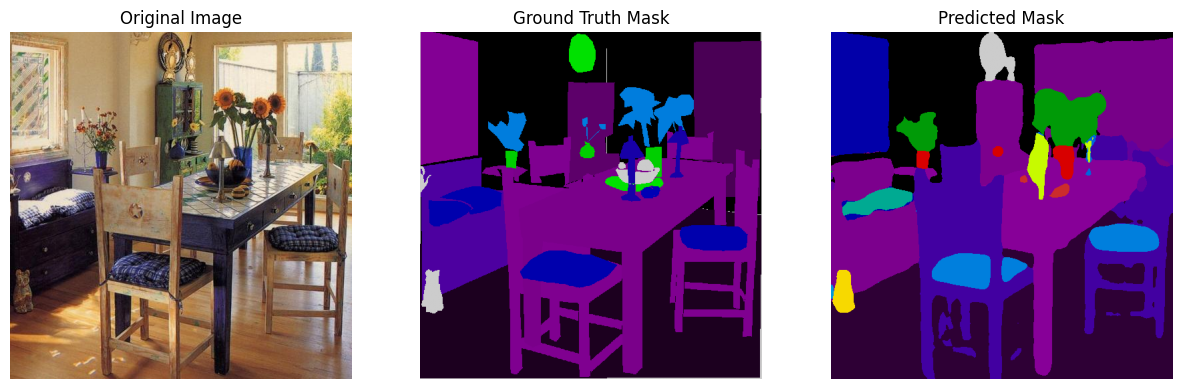

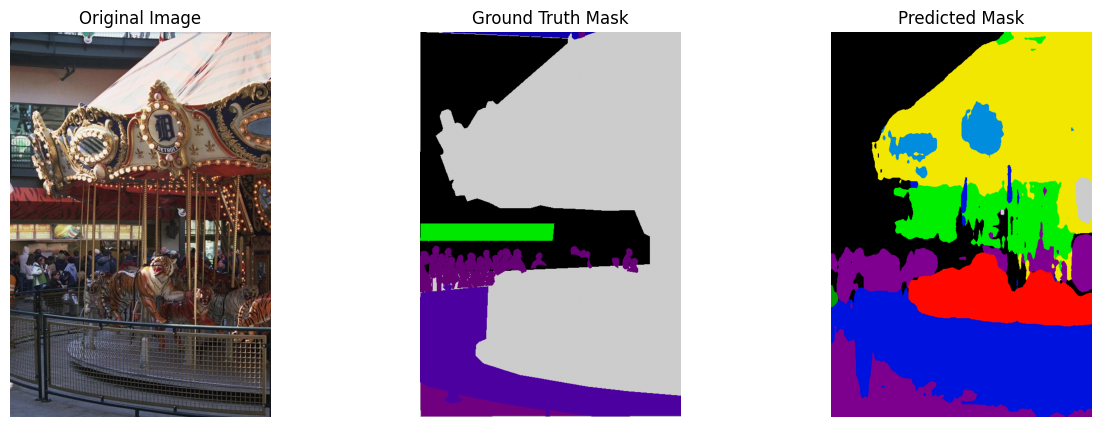

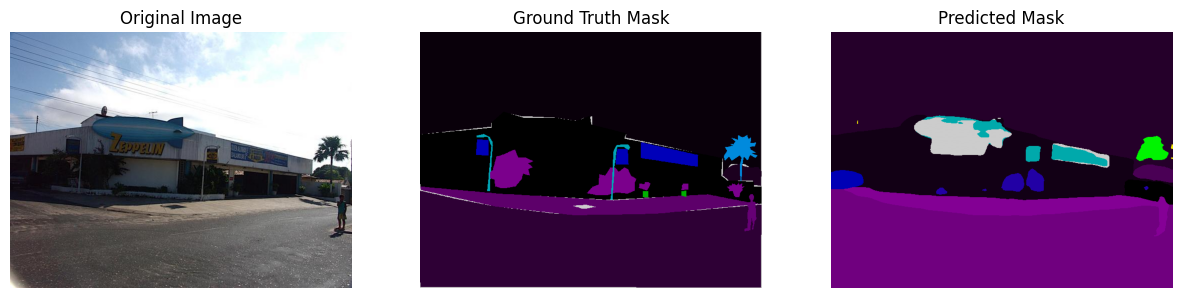

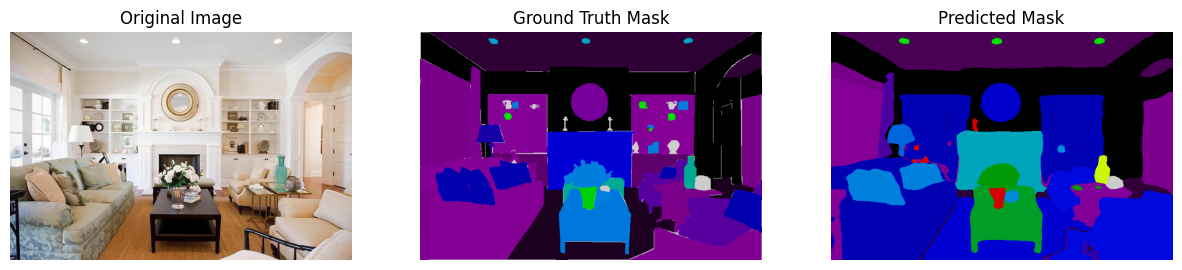

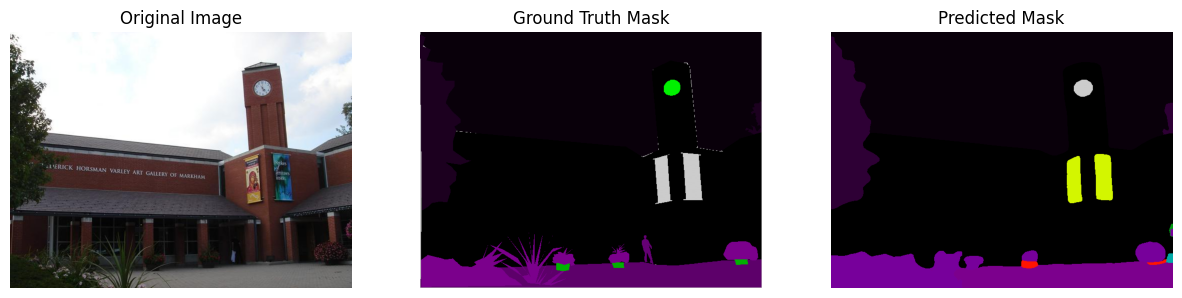

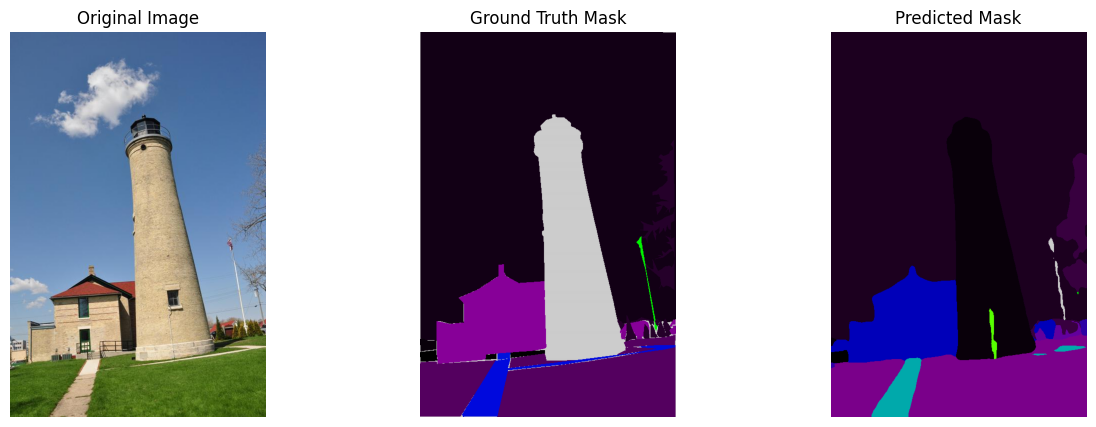

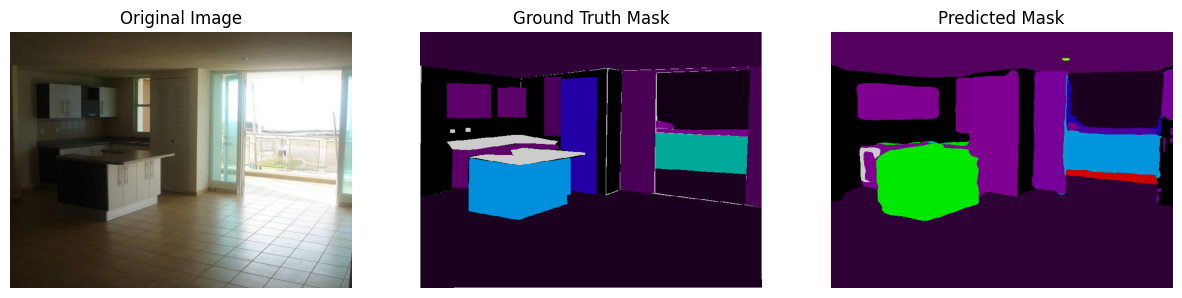

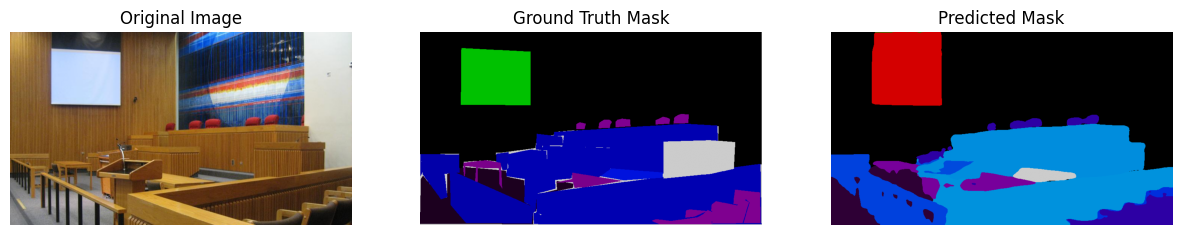

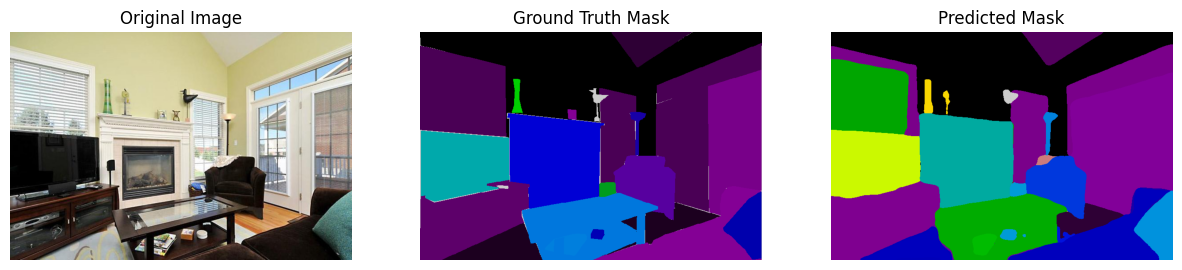

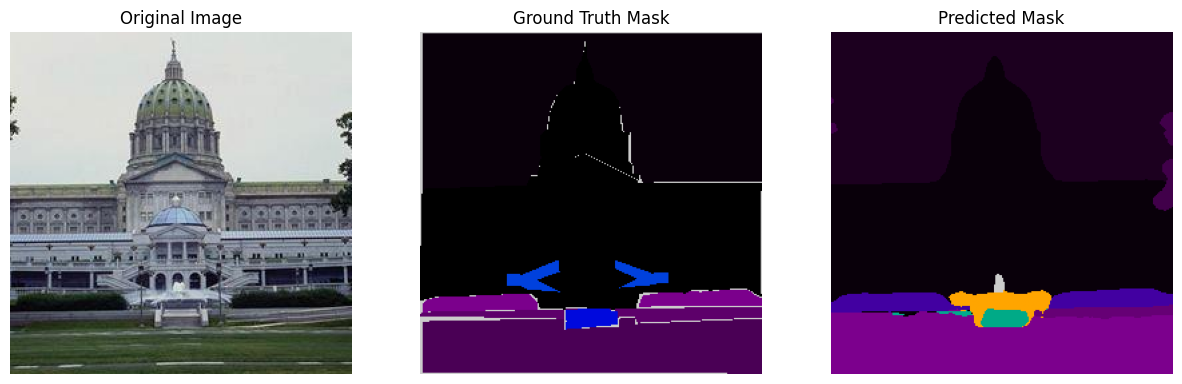

In [ ]:
# -------------------------
# 8. Visualize Random Samples
# -------------------------
sample_indices = random.sample(range(len(val_images)), 10)

for idx in sample_indices:
    img_path = val_images[idx]
    gt_path = val_masks[idx]

    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    seg_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].cpu().numpy()

    gt_mask = np.array(Image.open(gt_path))
    gt_mask_corrected = np.where(gt_mask == 0, 255, gt_mask - 1).astype(np.uint8)
    gt_mask_resized = np.array(Image.fromarray(gt_mask_corrected).resize(
        (seg_map.shape[1], seg_map.shape[0]), Image.NEAREST
    ))

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt_mask_resized, cmap="nipy_spectral")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(seg_map, cmap="nipy_spectral")
    plt.title("Predicted Mask")
    plt.axis("off")
    plt.show()


In [ ]:
# -------------------------
# 9. Conclusion
# -------------------------
print("""
✅ Project Complete: Semantic Segmentation with Mask2Former (Swin-Base) on ADE20K
- Evaluated 500 validation images
- Mean IoU: ~0.46
- Mean Accuracy: ~0.63
- Model performs well on large/common objects; struggles with small/rare objects
- Pretrained model provides strong baseline without fine-tuning
""")



✅ Project Complete: Semantic Segmentation with Mask2Former (Swin-Base) on ADE20K
- Evaluated 500 validation images
- Mean IoU: ~0.46
- Mean Accuracy: ~0.63
- Model performs well on large/common objects; struggles with small/rare objects
- Pretrained model provides strong baseline without fine-tuning

